<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/19_NeuralNetwork_MLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network(MLP)로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존(train→test)**과 **정보누수 방지**가 핵심입니다.


## 🧠 알고리즘 상세 설명: MLP (Multi-Layer Perceptron)

MLP는 인간의 뇌 신경망을 모방한 가장 기본적인 딥러닝 구조입니다. 이 모델은 단순히 선형적인 관계를 찾는 것을 넘어, 복잡하고 비선형적인 데이터의 패턴을 학습할 수 있습니다.

### 1. 주요 구성 요소
1. 입력층 (Input Layer):
   - 모델이 학습할 데이터(피처)가 처음 들어오는 곳입니다.
   - 본 예제에서는 7개의 기술적 지표(ret_lag, ma_gap, vol10)가 입력값($x_1, x_2, ..., x_7$)이 됩니다.

2. 은닉층 (Hidden Layers):
   - 입력 데이터의 복잡한 특징을 추출하는 '생각'의 단계입니다.
   - 각 층의 노드는 이전 층에서 온 신호에 가중치($w$)를 곱하고 편향($b$)을 더한 뒤, 활성화 함수를 통과시킵니다.
   - 본 모델은 (32, 16) 구조로, 첫 번째 층에 32개, 두 번째 층에 16개의 노드가 배치되어 있습니다.

3. 출력층 (Output Layer):
   - 최종 결과를 내놓는 곳입니다. 이진 분류 문제에서는 0(하락) 또는 1(상승)의 확률을 계산합니다.

### 2. 핵심 수학적 원리
- 노드의 연산: $z = \sum (w_i \cdot x_i) + b$
- 활성화 함수 (ReLU): $f(z) = \max(0, z)$
  - ReLU는 음수 신호는 차단하고 양수 신호만 통과시켜 신경망이 복잡한 비선형 관계를 학습할 수 있게 돕습니다.
- 손실 함수 (Loss Function):
  - 모델이 예측한 값과 실제 정답 사이의 오차를 측정합니다.

### 3. 학습 과정: 역전파 (Backpropagation)
1. 순전파 (Forward Propagation): 입력을 넣어서 예측값을 계산합니다.
2. 오차 계산: 실제 값과 예측 값의 차이를 구합니다.
3. 역전파 (Backpropagation): 오차를 뒤에서부터 앞으로 전달하며, 오차를 줄이는 방향으로 모든 가중치($w$)와 편향($b$)을 미세하게 수정합니다.
4. 반복: 이 과정을 수천 번 반복(max_iter=2000)하여 최적의 모델을 완성합니다.

### ⚠️ 주의사항
- MLP는 데이터의 스케일(단위)에 매우 민감합니다. 따라서 모든 데이터를 평균 0, 표준편차 1로 만드는 StandardScaler 과정이 필수입니다.

## 0) 환경 준비
```bash
pip install yfinance
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [2]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 248


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성(Feature Engineering)

### 🔍 피처(Feature) 상세 설명
모델이 시장의 상태를 구분하기 위해 사용하는 7가지 지표입니다.

ret_lag1 ~ ret_lag10 (Lagged Returns):
- 설명: 각각 1, 2, 3, 5, 10일 전의 주가 수익률입니다.
- 의도: 과거의 수익률 패턴이 시장 상태 결정에 어떤 영향을 주는지 확인합니다.

ma_gap (MA Cross Over Distance):
- 계산: (5일 이동평균 / 20일 이동평균) - 1.0
- 설명: 단기 평균 가격과 중기 평균 가격 사이의 거리입니다.
- 의도: 현재 주가가 단기적으로 과열되었는지 또는 추세가 전환되는 시점(골든/데드크로스)인지를 판단합니다.

vol10 (Rolling Volatility):
- 계산: 최근 10일간 수익률의 표준편차
- 설명: 시장의 위험도와 변동폭을 측정합니다.
- 의도: 공포 장세(고변동성)와 안정 장세(저변동성)를 구분하는 핵심 지표입니다.

In [3]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 229


## 3) 타깃/분할(시간 순서 보존)


In [4]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (182, 7) Test: (46, 7)


## 4) 모델 학습: MLP(Multi-Layer Perceptron)

### 🧠 머신러닝 모델 상세 설명
본 예제에서 사용한 MLP는 인공신경망의 가장 기본적인 형태입니다.

- 구조: 입력층(Input) -> 은닉층(Hidden Layers) -> 출력층(Output)
- 작동 원리: 각 층의 노드들은 가중치(Weights)와 편향(Bias)으로 연결되어 있으며, 활성화 함수를 통해 비선형적인 패턴을 학습합니다.
- 수식:
  $y = f(\sum w_i x_i + b)$
  - x: 입력 피처
  - w: 가중치 (학습 대상)
  - b: 편향 (학습 대상)
  - f: 활성화 함수 (본 모델에서는 ReLU 사용)

### 🛠 모델 설정
- Hidden Layer: (32, 16) - 32개의 노드와 16개의 노드를 가진 두 개의 은닉층을 쌓아 복잡한 관계를 학습합니다.
- StandardScaler: 신경망은 입력 데이터의 스케일에 민감하므로 평균 0, 표준편차 1로 변환하는 과정이 필수적입니다.

In [9]:
from sklearn.neural_network import MLPClassifier

# MLP는 스케일링이 매우 중요합니다.
# hidden_layer_sizes=(32, 16): 32개, 16개 노드를 가진 2개의 은닉층 사용
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(32,16),
                          activation='relu',
                          alpha=1e-3,
                          max_iter=2000,
                          random_state=42))
])
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(alpha=0.001, hidden_layer_sizes=(32, 16),
                               max_iter=2000, random_state=42))])

## 5) 평가


모델 정확도 (Accuracy): 0.4348
ROC-AUC 점수: 0.4762

상세 분류 보고서 (Classification report):
              precision    recall  f1-score   support

           0     0.3529    0.2857    0.3158        21
           1     0.4828    0.5600    0.5185        25

    accuracy                         0.4348        46
   macro avg     0.4178    0.4229    0.4172        46
weighted avg     0.4235    0.4348    0.4260        46



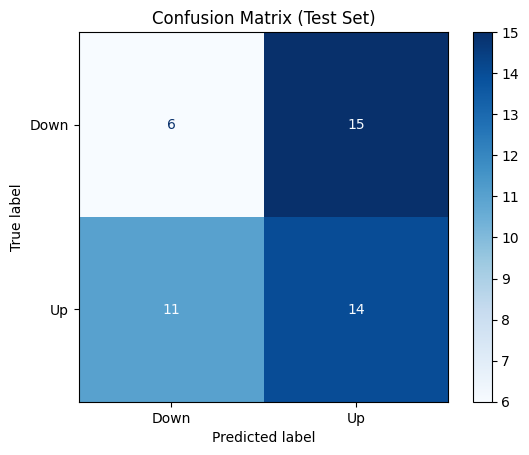

In [12]:
y_pred = model.predict(X_test)

if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
print(f"모델 정확도 (Accuracy): {acc:.4f}")
if auc is not None:
    print(f"ROC-AUC 점수: {auc:.4f}")
print("\n상세 분류 보고서 (Classification report):")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()

## 6) 방향 요약 + 다음 거래일 예측


In [7]:
import numpy as np
import pandas as pd

prediction_counts = np.bincount(y_pred)
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

last_day_features = X.iloc[-1].values.reshape(1, -1)
next_day_prediction = model.predict(last_day_features)
prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 17 건
Predicted Up (상승): 29 건
다음 거래일 예측 (날짜: 2026-03-25): 하락 (Down)


## ✅ 마지막 시각화(결과를 눈으로 확인)
마지막 셀은 반드시 그래프가 출력되도록 구성했습니다.


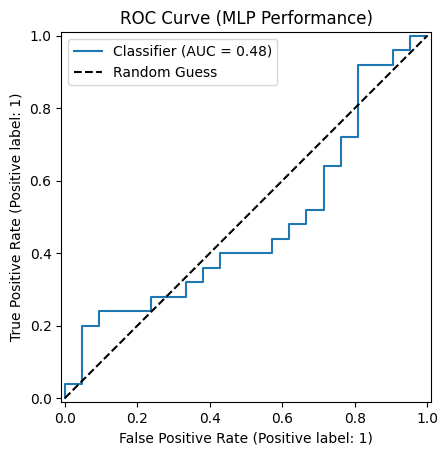

그래프 해석: 곡선 아래 면적(AUC)이 0.5보다 크면 무작위 예측보다 나은 성능을 의미합니다.


In [13]:
# ROC Curve 시각화 및 해석
y_proba = model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve (MLP Performance)')
plt.legend()
plt.show()

print("그래프 해석: 곡선 아래 면적(AUC)이 0.5보다 크면 무작위 예측보다 나은 성능을 의미합니다.")

## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
